# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre:** Angélica Guadalupe Pulido Reyes
#### **Matrícula:** A01797179

Modelos para predicción de un problema de serie de tiempo:

* **1. Modelo ingenuo**
* **2. Modelo ARIMA**
* **3. Modelo Prophet**
* **4. Modelo LSTM**

### **PRE MODELOS**

In [85]:
## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++
#librerias
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [86]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/monthly_champagne_sales.csv')

In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
df.head()

,Month,Sales
0,1964-01,2815
1,1964-02,2672
2,1964-03,2755
3,1964-04,2721
4,1964-05,2946


In [89]:
#Renombrar para prophet
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

In [90]:
#info inicial
df.head()

,ds,y
0,1964-01-01,2815
1,1964-02-01,2672
2,1964-03-01,2755
3,1964-04-01,2721
4,1964-05-01,2946


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      105 non-null    datetime64[ns]
 1   y       105 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.8 KB


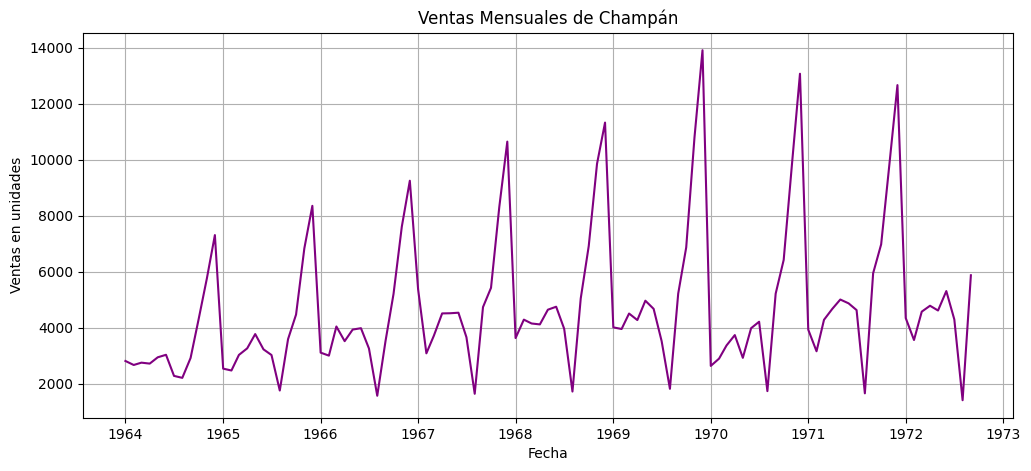

In [92]:
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'], 'b-', color='purple')
plt.title('Ventas Mensuales de Champán')
plt.xlabel('Fecha')
plt.ylabel('Ventas en unidades')
plt.grid(True)
plt.show()

In [93]:
#dividir os conjuntos

#copia
df_cham = df.copy().set_index('ds')
df_cham.index.freq = 'MS' #mensual

#dividir de entrenamiento y prueba, < 12 meses
train = df_cham.iloc[:-12]
test = df_cham.iloc[-12:]

print(f"\nDatos de entrenamiento: {train.shape[0]} meses")
print(f"Datos de prueba: {test.shape[0]} meses")


Datos de entrenamiento: 93 meses
Datos de prueba: 12 meses


### **MODELO INGENUO**

In [94]:
#modelo INGENUO

test['y'].values
history = [x for x in train['y']]
predictions = list()

#bucle para hacer predicciones
for i in range(len(test)):
  yhat = history[-1] #ultimo valor que se conoce
  predictions.append(yhat) #se agrega la prediccion a la lista
  obs  = test.iloc[i]['y'] #para sacar el 'esperado real'
  history.append(obs) #se agrega el 'esperado real'
  print(f'Esperado REAL = {obs} --> Predicción = {yhat}')

rmse_ingenuo = np.sqrt(mean_squared_error(test['y'].values, predictions)) #calsulo del RMSE con la raíz
print(f'\nRMSE de modelo INGENUO: = {rmse_ingenuo:.2f}')

Esperado REAL = 6981 --> Predicción = 5951
Esperado REAL = 9851 --> Predicción = 6981
Esperado REAL = 12670 --> Predicción = 9851
Esperado REAL = 4348 --> Predicción = 12670
Esperado REAL = 3564 --> Predicción = 4348
Esperado REAL = 4577 --> Predicción = 3564
Esperado REAL = 4788 --> Predicción = 4577
Esperado REAL = 4618 --> Predicción = 4788
Esperado REAL = 5312 --> Predicción = 4618
Esperado REAL = 4298 --> Predicción = 5312
Esperado REAL = 1413 --> Predicción = 4298
Esperado REAL = 5877 --> Predicción = 1413

RMSE de modelo INGENUO: = 3135.48


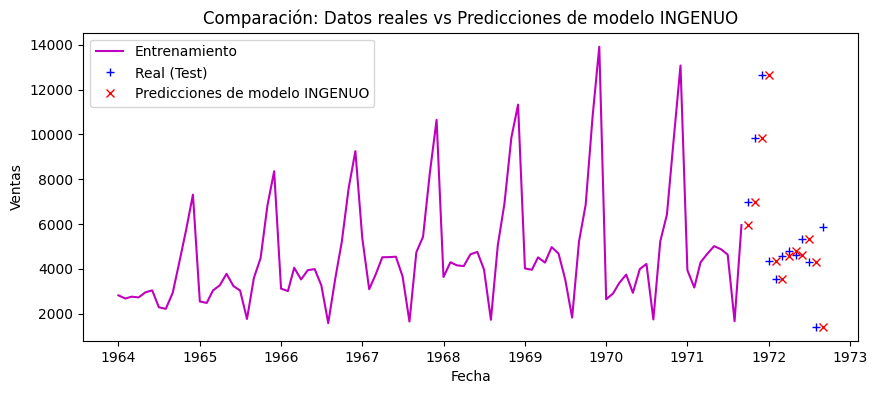

In [95]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(train['y'], '-m', label='Entrenamiento') #m=magenta, k=negro, c=cian
plt.plot(test['y'], '+b', label='Real (Test)')
plt.plot(test.index, predictions, 'xr', label='Predicciones de modelo INGENUO')
plt.title('Comparación: Datos reales vs Predicciones de modelo INGENUO')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

### **ARIMA**

In [96]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.arima.model import ARIMA

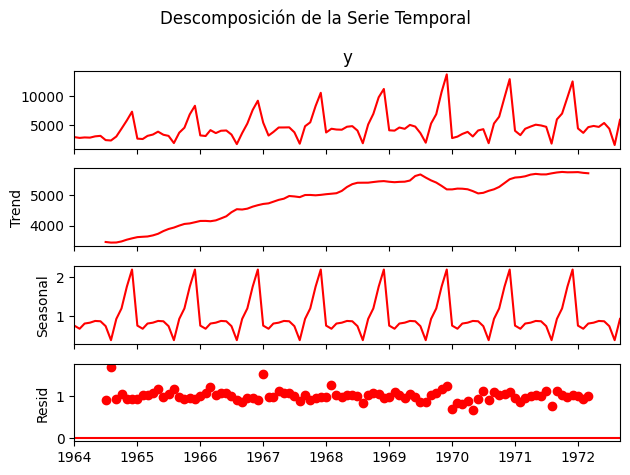

In [97]:
#grafico de descomposicion
decomposition = seasonal_decompose(df.set_index('ds')['y'], model='multiplicative', period=12)
fig = decomposition.plot()
for ax in fig.get_axes():
    for line in ax.get_lines():
        line.set_color('red')
plt.suptitle('Descomposición de la Serie Temporal')
plt.tight_layout()
plt.show()

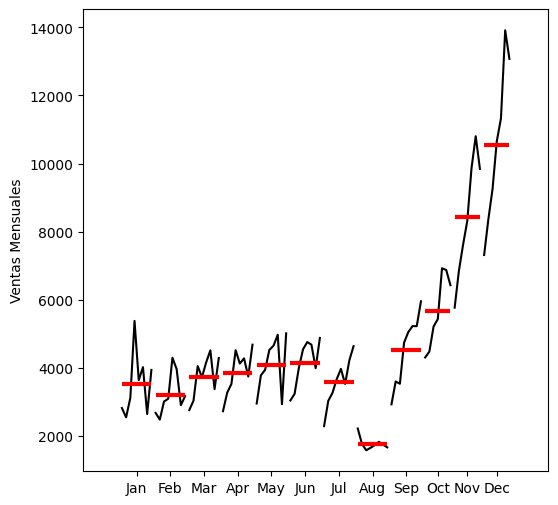

In [98]:
#estacional mensual
fig = month_plot(train['y'].resample('M').mean(), ylabel='Ventas Mensuales')
fig.set_size_inches(6, 6)
plt.show()

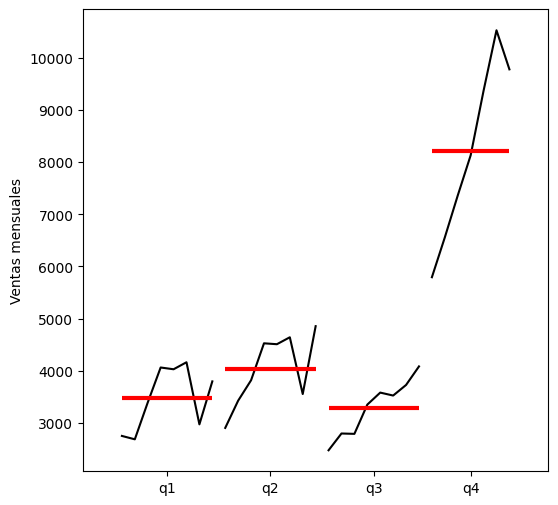

In [99]:
#estacional por cuartil
fig = quarter_plot(train['y'].resample('Q').mean(), ylabel='Ventas mensuales')
fig.set_size_inches(6, 6)
plt.show()

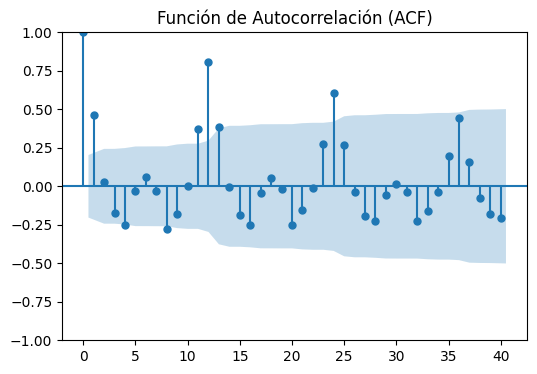

In [100]:
#autocorrelacion ACF
fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(train['y'], lags=40, ax=ax)
plt.title('Función de Autocorrelación (ACF)')
plt.show()

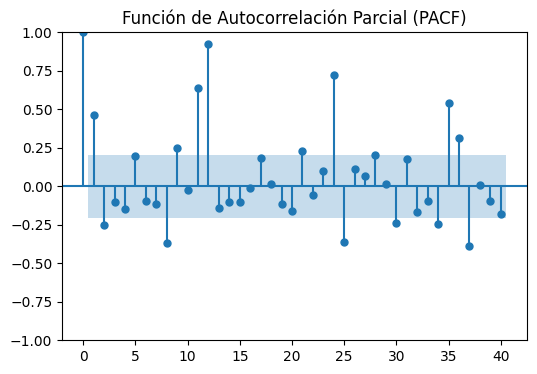

In [101]:
#autocorrelacion PACF
fig, ax = plt.subplots(figsize=(6, 4))
plot_pacf(train['y'], lags=40, ax=ax, method="ols")
plt.title('Función de Autocorrelación Parcial (PACF)')
plt.show()

In [102]:
#diferencia en el tiempo
def difference(dataset, interval=1):
  diff = [dataset[i] - dataset[i - interval] for i in range(interval, len(dataset))]
  return np.array(diff)

#estacionalidad
def inverse_difference(history, yhat, interval=1):
  return yhat + history[-interval]

history = [x for x in train['y'].values]
predictions = []

In [103]:
history = [x for x in train['y'].values]
predictions = list()

for i in range(len(test['y'])):
  months_in_year = 12
  diff = difference(history, months_in_year)

  arima = ARIMA(diff, order=(3, 0, 13))
  model_fit = arima.fit(method_kwargs={'maxiter': 300})
  yhat = model_fit.forecast()[0]
  yhat = inverse_difference(history, yhat, months_in_year)
  predictions.append(yhat)
  #observaciones
  obs = test.iloc[i]['y']
  history.append(obs)

  print(f'Esperado REAL = {obs} --> Predicción = {yhat:.2f}')

  #error RMSE
rmse_arima = np.sqrt(mean_squared_error(test['y'].values, predictions))
print(f'\nError-Modelo-ARIMA: RMSE: {rmse_arima:.2f}')


Esperado REAL = 6981 --> Predicción = 6726.53
Esperado REAL = 9851 --> Predicción = 9898.72
Esperado REAL = 12670 --> Predicción = 13641.25
Esperado REAL = 4348 --> Predicción = 4083.35
Esperado REAL = 3564 --> Predicción = 3728.55
Esperado REAL = 4577 --> Predicción = 4256.12
Esperado REAL = 4788 --> Predicción = 5060.37
Esperado REAL = 4618 --> Predicción = 5300.95
Esperado REAL = 5312 --> Predicción = 5045.04
Esperado REAL = 4298 --> Predicción = 4981.13
Esperado REAL = 1413 --> Predicción = 1692.17
Esperado REAL = 5877 --> Predicción = 5846.07

Error-Modelo-ARIMA: RMSE: 444.21


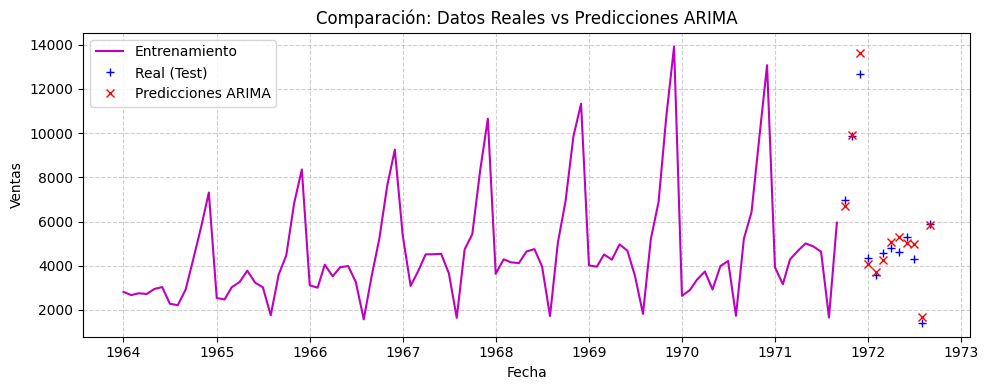

In [104]:
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(train['y'], '-m', label='Entrenamiento')
plt.plot(test['y'], '+b', label='Real (Test)')
plt.plot(test.index, predictions, 'xr', label='Predicciones ARIMA')
plt.title('Comparación: Datos Reales vs Predicciones ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Prophet**

In [105]:
from prophet import Prophet

In [106]:
#dividir conjuntos
train = df_cham.iloc[0:-12,:].reset_index()
test = df_cham.iloc[-12:,:].reset_index()

In [107]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=True,
                changepoint_prior_scale=10.,
                seasonality_prior_scale=18)
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3njvm8hd/ur9vsvca.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3njvm8hd/vy_g48af.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64148', 'data', 'file=/tmp/tmp3njvm8hd/ur9vsvca.json', 'init=/tmp/tmp3njvm8hd/vy_g48af.json', 'output', 'file=/tmp/tmp3njvm8hd/prophet_models2zf1kqs/prophet_model-20250620221713.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:17:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:17:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [108]:
#se calcula el RMSE
pred_prophet = model.predict(test)['yhat']
rmse_prophet = np.sqrt(mean_squared_error(test['y'].values, pred_prophet))
print(f'Error-Modelo-Prophet: RMSE: {rmse_prophet:.2f}')

Error-Modelo-Prophet: RMSE: 1322.27


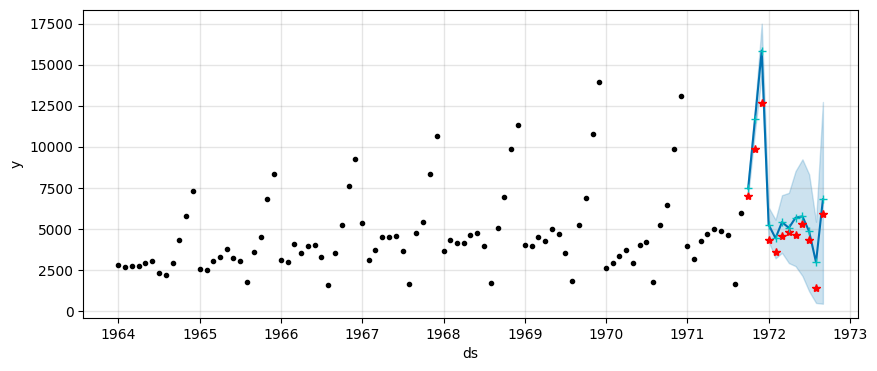

In [109]:
#Crear grafico
forecast = model.predict(test)

fig, ax = plt.subplots(figsize=(10, 4))
model.plot(forecast, ax=ax)
ax = plt.plot(test['ds'], test['y'], '*r')
ax = plt.plot(test['ds'], forecast['yhat'], '+c')

### **LSTM**

In [110]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
import keras
from keras import Sequential
from keras import layers
from keras.layers import Dense, LSTM

In [111]:
df_cham.head()
#inicia 1 de enero de 1964

,y
ds,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


In [112]:
df_cham.tail()
#acaba 1 de septiembre de 1972

,y
ds,
1972-05-01,4618
1972-06-01,5312
1972-07-01,4298
1972-08-01,1413
1972-09-01,5877


In [113]:
#definir funcion para la secuencia de tiempo
# se usa una ventana de tiempo
def secuencia_tiempo(data, window_size):
  X, y = [], []
  for i in range(window_size, len(data)):
    X.append(data[i-window_size:i]) #12 meses
    y.append(data[i]) #el siguiente mes que se va a predecir con base a las 12 anteriores
  return np.array(X), np.array(y)

In [114]:
window_size = 12
X, y = secuencia_tiempo(df_cham['y'].values, window_size)
print(X.shape)

(93, 12)


In [115]:
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)

(93, 12, 1)


In [116]:
#dividimos conjuntos

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape)
print(X_test.shape)

(74, 12, 1)
(19, 12, 1)


In [117]:
#modelo LSTM

model = Sequential()
model.add(LSTM(50,
               return_sequences=True, #para que tenga el formato de las tres dimensiones
               activation='relu',
               recurrent_activation='sigmoid'
               ))
model.add(LSTM(150, return_sequences=False, activation='relu'))
model.add(Dense(1))

#compilar
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.RootMeanSquaredError()],
              )

history = model.fit(X_train, y_train, epochs=65, batch_size=32, validation_data=(X_test, y_test)) #32 periodos

Epoch 1/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 542ms/step - loss: 30334714.0000 - root_mean_squared_error: 5505.6709 - val_loss: 32077306.0000 - val_root_mean_squared_error: 5663.6831
Epoch 2/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 30982424.0000 - root_mean_squared_error: 5561.5020 - val_loss: 27519460.0000 - val_root_mean_squared_error: 5245.8994
Epoch 3/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 27405538.0000 - root_mean_squared_error: 5233.2402 - val_loss: 27799770.0000 - val_root_mean_squared_error: 5272.5488
Epoch 4/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 23887826.0000 - root_mean_squared_error: 4886.8481 - val_loss: 19678934.0000 - val_root_mean_squared_error: 4436.0942
Epoch 5/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 19382942.0000 - root_mean_squared_error: 4398.6914 - val_loss: 18230576.0000 - val_root_mean_squared_error: 4269.7280
Epoch 6/65
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 14513046.0000 - root_mean_squared_error: 3808.7527 - val_loss: 1538

In [118]:
pred_LSTM = model.predict(X_test[-12:])
y_test_real = y_test[-12:].reshape(-1, 1)

rmse_LSTM = np.sqrt(mean_squared_error(y_test_real, pred_LSTM))
print(f'Error-Modelo-LSTM: RMSE: {rmse_LSTM:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
Error-Modelo-LSTM: RMSE: 1427.77


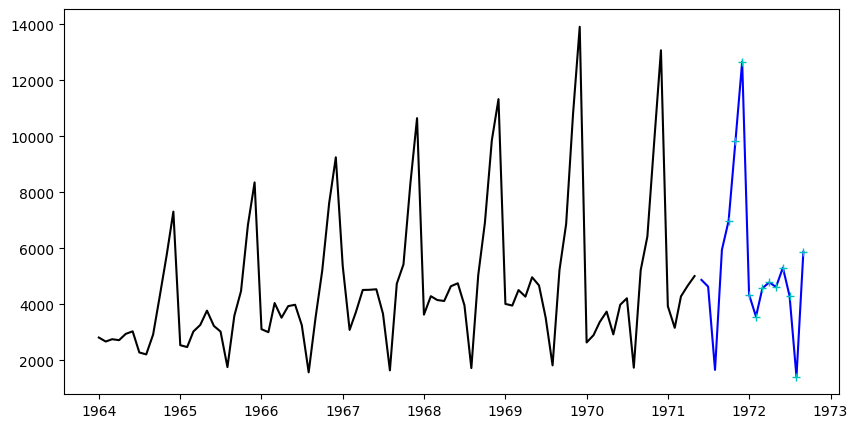

In [119]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = plt.plot(df['ds'][0:int(0.85 * len(df))], df['y'][0:int(0.85 * len(df))], '-k')
ax = plt.plot(df['ds'][int(0.85 * len(df)):], df['y'][int(0.85 * len(df)):], '-b')
ax = plt.plot(df['ds'][-12:], df['y'][-12:], '+c')

### Resumen de modelos

In [120]:
print(f'RMSE de modelo INGENUO: = {rmse_ingenuo:.2f}')
print(f'Error-Modelo-ARIMA: RMSE: {rmse_arima:.2f}')
print(f'Error-Modelo-Prophet: RMSE: {rmse_prophet:.2f}')
print(f'Error-Modelo-LSTM: RMSE: {rmse_LSTM:.2f}')

RMSE de modelo INGENUO: = 3135.48
Error-Modelo-ARIMA: RMSE: 444.21
Error-Modelo-Prophet: RMSE: 1322.27
Error-Modelo-LSTM: RMSE: 1427.77


### ***Conclusiones***

## **<<< Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo >>>**